In [ ]:
import os, argparse, random, numpy as np
import torch, torch.nn as nn, torch.nn.functional as F

class AE(nn.Module):
    def __init__(self, embed_dim=200, num_views=3, feature_dims=[1000, 1000, 500], hidden_dims=[512, 512, 512]):
        super(AE, self).__init__()
        self.embed_dim = embed_dim; self.num_views = num_views; self.feature_dims = feature_dims; self.hidden_dims = hidden_dims
        self.encoder_list = nn.ModuleList([nn.Sequential(nn.Linear(feature_dims[i], hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(),
                                                         nn.Linear(hidden_dims[i], embed_dim)) for i in range(num_views)])
        self.fusion_net = nn.Linear(num_views*embed_dim, embed_dim)
        self.decoder_list = nn.ModuleList([nn.Sequential(nn.Linear(embed_dim, hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(),
                                                         nn.Linear(hidden_dims[i], feature_dims[i])) for i in range(num_views)])
    
    def forward(self, x):
        encoded_output_list = [self.encoder_list[i](x[i]) for i in range(self.num_views)]
        encoded_output = self.fusion_net(torch.cat(encoded_output_list, dim=1))
        decoded_output_list = [self.decoder_list[i](encoded_output) for i in range(self.num_views)]
        return decoded_output_list, encoded_output
    
    def forward_embedding(self, x):
        encoded_output_list = [self.encoder_list[i](x[i]) for i in range(self.num_views)]
        encoded_output = self.fusion_net(torch.cat(encoded_output_list, dim=1))
        return encoded_output
    
    def reconstruction_loss(self, x):
        decoded_output_list, _ = self.forward(x)
        return sum([F.mse_loss(decoded_output_list[v], x[v], reduction='mean') for v in range(self.num_views)])
    
class DAE(nn.Module):
    def __init__(self, embed_dim=200, num_views=3, feature_dims=[1000, 1000, 500], hidden_dims=[512, 512, 512], noise_factor=0.1):
        super(DAE, self).__init__()
        self.embed_dim = embed_dim; self.num_views = num_views; self.feature_dims = feature_dims; self.hidden_dims = hidden_dims; self.noise_factor = noise_factor
        self.encoder_list = nn.ModuleList([nn.Sequential(nn.Linear(feature_dims[i], hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(),
                                                         nn.Linear(hidden_dims[i], embed_dim)) for i in range(num_views)])
        self.fusion_net = nn.Linear(num_views*embed_dim, embed_dim)
        self.decoder_list = nn.ModuleList([nn.Sequential(nn.Linear(embed_dim, hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(),
                                                         nn.Linear(hidden_dims[i], feature_dims[i])) for i in range(num_views)])
    
    def forward(self, x):
        if self.training:
            x = [x[i] + self.noise_factor * torch.randn_like(x[i]) for i in range(self.num_views)]
        encoded_output_list = [self.encoder_list[i](x[i]) for i in range(self.num_views)]
        encoded_output = self.fusion_net(torch.cat(encoded_output_list, dim=1))
        decoded_output_list = [self.decoder_list[i](encoded_output) for i in range(self.num_views)]
        return decoded_output_list, encoded_output
    
    def forward_embedding(self, x):
        encoded_output_list = [self.encoder_list[i](x[i]) for i in range(self.num_views)]
        encoded_output = self.fusion_net(torch.cat(encoded_output_list, dim=1))
        return encoded_output

    def reconstruction_loss(self, x):
        decoded_output_list, _ = self.forward(x)
        return sum([F.mse_loss(decoded_output_list[v], x[v], reduction='mean') for v in range(self.num_views)])
    
class DUCMME(nn.Module):
    def __init__(self, embed_dim=200, num_samples=10000, num_views=3, feature_dims=[1000, 1000, 500], hidden_dims=[512, 512, 512], n_clusters=10, alpha=1.0):
        super(DUCMME, self).__init__()
        self.embed_dim = embed_dim; self.num_samples = num_samples; self.num_views = num_views; self.feature_dims = feature_dims; self.hidden_dims = hidden_dims; self.n_clusters = n_clusters; self.alpha = alpha
        # 1. Multi-view Feature Extraction by Fusion-Net
        self.fusion_net_encoder = nn.ModuleList([nn.Sequential(nn.Linear(feature_dims[i], hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(),
                                                               nn.Linear(hidden_dims[i], embed_dim)) for i in range(num_views)]) # encode each view
        self.fusion_net_mha = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=10, batch_first=True) # batch_first=True: (batch_size, seq_len, hidden_dim)
        self.fusion_net_linear = nn.Linear(3*embed_dim, embed_dim) # linear projection of the fused encoded features
        # 2. Uncertainty-Aware Reconstruction by Reconstruction-Net and Uncertainty-Net
        self.reconstruct_net_list = nn.ModuleList([nn.Sequential(nn.Linear(self.embed_dim, hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(), 
                                                                 nn.Linear(hidden_dims[i], feature_dims[i])) for i in range(num_views)]) # reconstruct each view
        self.uncertainty_net_list = nn.ModuleList([nn.Sequential(nn.Linear(self.embed_dim, hidden_dims[i]), nn.BatchNorm1d(hidden_dims[i]), nn.ReLU(), 
                                                                 nn.Linear(hidden_dims[i], feature_dims[i])) for i in range(num_views)]) # predict uncertainty for each view
        # 3. Deep Embedding Clustering by DEC
        self._cluster_centers = nn.Parameter(torch.Tensor(self.n_clusters, self.embed_dim))
        nn.init.xavier_uniform_(self._cluster_centers.data)
        
    def forward_embedding(self, x):
        encoded_output_list = [self.fusion_net_encoder[i](x[i]) for i in range(self.num_views)] # encode each view
        encoded_output_list = torch.stack(encoded_output_list, dim=1) # stack the encoded features from all views, (batch_size, num_views, embed_dim)
        encoded_output_list, _ = self.fusion_net_mha(encoded_output_list, encoded_output_list, encoded_output_list) # fuse the encoded features from all views by a multihead attention, (batch_size, num_views, embed_dim)
        encoded_output_list = encoded_output_list.contiguous().view(encoded_output_list.shape[0], -1) # flatten the encoded features, (batch_size, num_views*embed_dim)
        embedding = self.fusion_net_linear(encoded_output_list) # linear projection of the fused encoded features
        return embedding # get the embedding of the latent space H, (batch_size, embed_dim)

    def forward_uncertainty_aware_reconstruction(self, x):
        embedding = self.forward_embedding(x) # shape: [batch_size, embed_dim]
        reconstructions = [self.reconstruct_net_list[i](embedding) for i in range(self.num_views)] # reconstruct each view
        uncertainties = [self.uncertainty_net_list[i](embedding) for i in range(self.num_views)] # predict uncertainty for each view
        return reconstructions, uncertainties
        
    def forward_similarity_matrix_q(self, x): # calculate the similarity matrix q using t-distribution
        embedding = self.forward_embedding(x) # shape: [batch_size, embed_dim]
        q = 1.0 / (1.0 + torch.sum((embedding.unsqueeze(1) - self._cluster_centers) ** 2, dim=2) / self.alpha) # shape: [batch_size, n_clusters]
        q = q ** ((self.alpha + 1.0) / 2.0) # , shape: [batch_size, n_clusters]
        q = q / torch.sum(q, dim=1, keepdim=True) # Normalize q to sum to 1 across clusters, shape: [batch_size, n_clusters]
        return q, embedding # q can be regarded as the probability of the sample belonging to each cluster
    
    @property
    def cluster_centers(self):
        return self._cluster_centers.data.detach().cpu().numpy() # shape: (n_clusters, embed_dim)
    
    @cluster_centers.setter
    def cluster_centers(self, centers): # shape: (n_clusters, embed_dim)
        centers = torch.tensor(centers, dtype=torch.float32, device=self._cluster_centers.device)
        self._cluster_centers.data.copy_(centers) # copy the cluster centers to the model, set the cluster centers to the new cluster centers
        
    @staticmethod
    def target_distribution(q):
        weight = q ** 2 / torch.sum(q, dim=0) # shape: [batch_size, n_clusters]
        p = weight / torch.sum(weight, dim=1, keepdim=True) # Normalize p to sum to 1 across clusters, shape: [batch_size, n_clusters]
        return p.clone().detach()
    
    def reconstruction_loss(self, x):
        x_rec, _ = self.forward_uncertainty_aware_reconstruction(x) # reconstruct each view and predict uncertainty
        return sum([F.mse_loss(x_rec[v], x[v], reduction='mean') for v in range(self.num_views)]) # sum the losses from all views
    
    def uncertainty_aware_reconstruction_loss(self, x):
        x_rec, log_sigma_2 = self.forward_uncertainty_aware_reconstruction(x) # reconstruct each view and predict uncertainty
        return sum([0.5 * torch.mean((x_rec[v] - x[v])**2 * torch.exp(-log_sigma_2[v]) + log_sigma_2[v]) for v in range(self.num_views)]) # uncertainty is equal to log_sigma_2
    
    def clustering_loss(self, x, p):
        q, _ = self.forward_similarity_matrix_q(x) # shape: [batch_size, n_clusters]
        return F.kl_div(q.log(), p, reduction='batchmean') # shape: ()

In [ ]:
def predict_embedding_with_HDUR_AE_DAE(data, data_views, data_samples, data_features, data_categories):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = DUCMME(embed_dim=20, feature_dims=data_features, num_views=data_views, hidden_dims=[512, 512, 512], num_samples=data_samples, n_clusters=data_categories, alpha=1.0).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        loss = model.reconstruction_loss(data)
        loss.backward()
        optimizer.step()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        loss = model.uncertainty_aware_reconstruction_loss(data)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        embeddings_HDUR = model.forward_embedding(data).cpu().numpy()
    
    model_AE = AE(embed_dim=20, num_views=data_views, feature_dims=data_features, hidden_dims=[512, 512, 512]).to(device)
    optimizer = torch.optim.Adam(model_AE.parameters(), lr=0.001)
    for epoch in range(100):
        model_AE.train()
        optimizer.zero_grad()
        loss = model_AE.reconstruction_loss(data)
        loss.backward()
        optimizer.step()
    model_AE.eval()
    with torch.no_grad():
        embeddings_AE = model_AE.forward_embedding(data).cpu().numpy()
    
    model_DAE = DAE(embed_dim=20, num_views=data_views, feature_dims=data_features, hidden_dims=[512, 512, 512], noise_factor=0.1).to(device)
    optimizer = torch.optim.Adam(model_DAE.parameters(), lr=0.001)
    for epoch in range(100):
        model_DAE.train()
        optimizer.zero_grad()
        loss = model_DAE.reconstruction_loss(data)
        loss.backward()
        optimizer.step()
    model_DAE.eval()
    with torch.no_grad():
        embeddings_DAE = model_DAE.forward_embedding(data).cpu().numpy()
    return embeddings_HDUR, embeddings_AE, embeddings_DAE

from _utils import MMDataset
random.seed(0); np.random.seed(0); torch.manual_seed(0); torch.cuda.manual_seed_all(0) # Set random seed for reproducibility
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dataset = MMDataset('./data/data_sc_multiomics/TEA/', concat_data=False)
data = [x.clone().to(device) for x in dataset.X]; label = dataset.Y.clone().numpy()
data_views = dataset.data_views; data_samples = dataset.data_samples; data_features = dataset.data_features; data_categories = dataset.categories
label_dict_TEA = dataset.get_label_to_name()
label_TEA = label

# Generate data with different noise levels from 0.1 to 1
data_noise_level_01 = [x.clone() for x in data]
for view in range(data_views):
    noise = np.random.normal(0, 0.1, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_01[view] = data_noise_level_01[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_noise_level_02 = [x.clone() for x in data]
for view in range(data_views):
    noise = np.random.normal(0, 0.2, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_02[view] = data_noise_level_02[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_noise_level_03 = [x.clone() for x in data]
for view in range(data_views):  
    noise = np.random.normal(0, 0.3, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_03[view] = data_noise_level_03[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_noise_level_04 = [x.clone() for x in data]
for view in range(data_views):
    noise = np.random.normal(0, 0.4, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_04[view] = data_noise_level_04[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_noise_level_05 = [x.clone() for x in data]
for view in range(data_views):
    noise = np.random.normal(0, 0.5, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_05[view] = data_noise_level_05[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_noise_level_06 = [x.clone() for x in data]
for view in range(data_views):
    noise = np.random.normal(0, 0.6, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_06[view] = data_noise_level_06[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_noise_level_07 = [x.clone() for x in data]
for view in range(data_views):
    noise = np.random.normal(0, 0.7, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_07[view] = data_noise_level_07[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_noise_level_08 = [x.clone() for x in data]
for view in range(data_views):
    noise = np.random.normal(0, 0.8, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_08[view] = data_noise_level_08[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_noise_level_09 = [x.clone() for x in data]
for view in range(data_views):
    noise = np.random.normal(0, 0.9, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_09[view] = data_noise_level_09[view] + torch.tensor(noise, dtype=torch.float32, device=device)
data_noise_level_10 = [x.clone() for x in data]
for view in range(data_views):
    noise = np.random.normal(0, 1, (data_samples, data_features[view]))
    noise = np.clip(noise, 0, None)
    data_noise_level_10[view] = data_noise_level_10[view] + torch.tensor(noise, dtype=torch.float32, device=device)

embedding_HDUR_00, embedding_AE_00, embedding_DAE_00 = predict_embedding_with_HDUR_AE_DAE(data, data_views, data_samples, data_features, data_categories)
embedding_HDUR_01, embedding_AE_01, embedding_DAE_01 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_01, data_views, data_samples, data_features, data_categories)
embedding_HDUR_02, embedding_AE_02, embedding_DAE_02 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_02, data_views, data_samples, data_features, data_categories)
embedding_HDUR_03, embedding_AE_03, embedding_DAE_03 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_03, data_views, data_samples, data_features, data_categories)
embedding_HDUR_04, embedding_AE_04, embedding_DAE_04 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_04, data_views, data_samples, data_features, data_categories)
embedding_HDUR_05, embedding_AE_05, embedding_DAE_05 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_05, data_views, data_samples, data_features, data_categories)
embedding_HDUR_06, embedding_AE_06, embedding_DAE_06 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_06, data_views, data_samples, data_features, data_categories)
embedding_HDUR_07, embedding_AE_07, embedding_DAE_07 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_07, data_views, data_samples, data_features, data_categories)
embedding_HDUR_08, embedding_AE_08, embedding_DAE_08 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_08, data_views, data_samples, data_features, data_categories)
embedding_HDUR_09, embedding_AE_09, embedding_DAE_09 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_09, data_views, data_samples, data_features, data_categories)
embedding_HDUR_10, embedding_AE_10, embedding_DAE_10 = predict_embedding_with_HDUR_AE_DAE(data_noise_level_10, data_views, data_samples, data_features, data_categories)

embedding_HDUR_list = [embedding_HDUR_00, embedding_HDUR_01, embedding_HDUR_02, embedding_HDUR_03, embedding_HDUR_04, embedding_HDUR_05, embedding_HDUR_06, embedding_HDUR_07, embedding_HDUR_08, embedding_HDUR_09, embedding_HDUR_10]
embedding_AE_list = [embedding_AE_00, embedding_AE_01, embedding_AE_02, embedding_AE_03, embedding_AE_04, embedding_AE_05, embedding_AE_06, embedding_AE_07, embedding_AE_08, embedding_AE_09, embedding_AE_10]
embedding_DAE_list = [embedding_DAE_00, embedding_DAE_01, embedding_DAE_02, embedding_DAE_03, embedding_DAE_04, embedding_DAE_05, embedding_DAE_06, embedding_DAE_07, embedding_DAE_08, embedding_DAE_09, embedding_DAE_10]

modality_rna shape: (25517, 50)
modality_protein shape: (25517, 47)
modality_atac shape: (25517, 30)


In [ ]:
from sklearn.cluster import KMeans
from _utils import clustering_acc, purity_score
from sklearn.metrics import normalized_mutual_info_score, rand_score, adjusted_rand_score, silhouette_score
import pandas as pd

def calculate_metrics(embedding, label):
    acc_list = []; nmi_list = []; ri_list = []; ari_list = []; asw_list = []; purity_list = []
    for i in range(5):
        label_pred = KMeans(n_clusters=12, n_init=20, random_state=i).fit_predict(embedding) # KMeans is not a deterministic method and the results are random for different initializations.
        acc_list.append(clustering_acc(label, label_pred) * 100); 
        nmi_list.append(normalized_mutual_info_score(label, label_pred) * 100)
        ri_list.append(rand_score(label, label_pred) * 100); 
        ari_list.append(adjusted_rand_score(label, label_pred) * 100)
        asw_list.append(silhouette_score(embedding, label_pred) * 100)
        purity_list.append(purity_score(label, label_pred) * 100)
        
    acc_mean = np.mean(acc_list); nmi_mean = np.mean(nmi_list); ri_mean = np.mean(ri_list); ari_mean = np.mean(ari_list); asw_mean = np.mean(asw_list); purity_mean = np.mean(purity_list)
    acc_std = np.std(acc_list); nmi_std = np.std(nmi_list); ri_std = np.std(ri_list); ari_std = np.std(ari_list); asw_std = np.std(asw_list); purity_std = np.std(purity_list)
    return acc_mean, nmi_mean, ri_mean, ari_mean, asw_mean, purity_mean, acc_std, nmi_std, ri_std, ari_std, asw_std, purity_std

def calculate_metrics_for_all_embeddings(embedding_list, label):
    acc_list = []; nmi_list = []; ri_list = []; ari_list = []; asw_list = []; purity_list = []
    # Create DataFrame with proper index from the start
    index_labels = [f'0.{i}' if i < 10 else '1.0' for i in range(len(embedding_list))]
    data_frame = pd.DataFrame(index=index_labels, columns=['acc_mean', 'nmi_mean', 'ri_mean', 'ari_mean', 'asw_mean', 'purity_mean', 'acc_std', 'nmi_std', 'ri_std', 'ari_std', 'asw_std', 'purity_std'])
    for idx, embedding in enumerate(embedding_list):
        acc_mean, nmi_mean, ri_mean, ari_mean, asw_mean, purity_mean, acc_std, nmi_std, ri_std, ari_std, asw_std, purity_std = calculate_metrics(embedding, label)
        print(1)
        data_frame.iloc[idx] = [acc_mean, nmi_mean, ri_mean, ari_mean, asw_mean, purity_mean, acc_std, nmi_std, ri_std, ari_std, asw_std, purity_std]
    return data_frame

data_frame_HDUR = calculate_metrics_for_all_embeddings(embedding_HDUR_list, label_TEA)
data_frame_AE = calculate_metrics_for_all_embeddings(embedding_AE_list, label_TEA)
data_frame_DAE = calculate_metrics_for_all_embeddings(embedding_DAE_list, label_TEA)
# 45 minutes to complete the calculation of the metrics for all embeddings

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
noise_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
methods = ['HDUR', 'AE', 'DAE']
colors = {'HDUR': '#1f77b4', 'AE': '#ff7f0e', 'DAE': '#2ca02c'}
# metrics = ['ACC', 'NMI', 'RI', 'ARI', 'ASW', 'Purity']
metrics = ['ASW']
metric_labels = {
    'ACC': 'Clustering Accuracy (%)',
    'NMI': 'Normalized Mutual Information (%)',
    'RI': 'Rand Index (%)',
    'ARI': 'Adjusted Rand Index (%)',
    'ASW': 'Average Silhouette Width (%)',
    'Purity': 'Purity Score (%)'
}
plot_data_list = []
for method_idx, method in enumerate(methods):
    if method == 'HDUR':
        df = data_frame_HDUR.copy()
    if method == 'AE':
        df = data_frame_AE.copy()
    if method == 'DAE':
        df = data_frame_DAE.copy()
    for metric in metrics:
        mean_col = f'{metric.lower()}_mean'
        std_col = f'{metric.lower()}_std'
        if mean_col in df.columns and std_col in df.columns:
            for idx, noise in enumerate(noise_levels):
                plot_data_list.append({'method': method, 'metric': metric, 'sigma': noise, 'mean': df.iloc[idx][mean_col], 'std': df.iloc[idx][std_col]})
plot_data = pd.DataFrame(plot_data_list)
plot_data.to_csv('./figure/hdur_sample_level/TEA/plot_data_noise_level.csv', index=False)

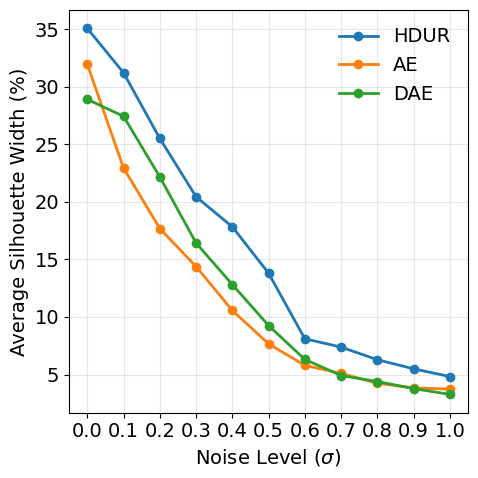

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
plt.rcParams['font.size'] = 14
methods = ['HDUR', 'AE', 'DAE']
colors = {'HDUR': '#1f77b4', 'AE': '#ff7f0e', 'DAE': '#2ca02c'}
# metrics = ['ACC', 'NMI', 'RI', 'ARI', 'ASW', 'Purity']
metrics = ['ASW']
metric_labels = {
    'ACC': 'Clustering Accuracy (%)',
    'NMI': 'Normalized Mutual Information (%)',
    'RI': 'Rand Index (%)',
    'ARI': 'Adjusted Rand Index (%)',
    'ASW': 'Average Silhouette Width (%)',
    'Purity': 'Purity Score (%)'
}
plot_data = pd.read_csv('./figure/hdur_sample_level/TEA/plot_data_noise_level.csv')
for metric in metrics:
    metric_data = plot_data[plot_data['metric'] == metric].copy()
    metric_data['method'] = pd.Categorical(metric_data['method'], categories=methods, ordered=True)
    metric_data = metric_data.sort_values(by=['method', 'sigma']).reset_index(drop=True)
    
    plt.figure(figsize=(5, 5))
    for method, g in metric_data.groupby('method', observed=True):
        color = colors[method]
        plt.plot(g['sigma'], g['mean'], label=method, marker='o', color=color, linewidth=2)
        # plt.fill_between(g['sigma'], g['mean'] - g['std'], g['mean'] + g['std'], alpha=0.3, color=color)
    
    # plt.xlabel(r'Noise Level ($\sigma$)', fontsize=12, fontweight='bold', color='black')
    # plt.xticks(np.arange(0.0, 1.1, 0.1), [f'{i:.1f}' for i in np.arange(0.0, 1.1, 0.1)], fontsize=11, fontweight='bold', color='black')
    # plt.ylabel(metric_labels[metric], fontsize=12, fontweight='bold', color='black')
    # plt.legend(loc='best', fontsize=11, frameon=False, prop={'weight': 'bold'})
    plt.xlabel(r'Noise Level ($\sigma$)', color='black')
    plt.xticks(np.arange(0.0, 1.1, 0.1), [f'{i:.1f}' for i in np.arange(0.0, 1.1, 0.1)], color='black')
    plt.ylabel(metric_labels[metric], color='black')
    plt.legend(loc='best', frameon=False)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'./figure/hdur_sample_level/TEA/stage_1_sample_uncertainty_noisy_condition_{metric}.png', dpi=400, bbox_inches='tight')
    plt.show()
